# 분석 단계별 프로세스 - 랜덤 포레스트 알고리즘

## 1. 라이브러리/데이터 불러오기

In [6]:
import os
import sklearn

import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

df_frame = pd.read_csv("../results/df_frame.csv")

df_frame.head()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


## 2. 데이터 종류 및 개수 확인

In [7]:
df_frame.head()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


In [8]:
df_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6168 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6168 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6168 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


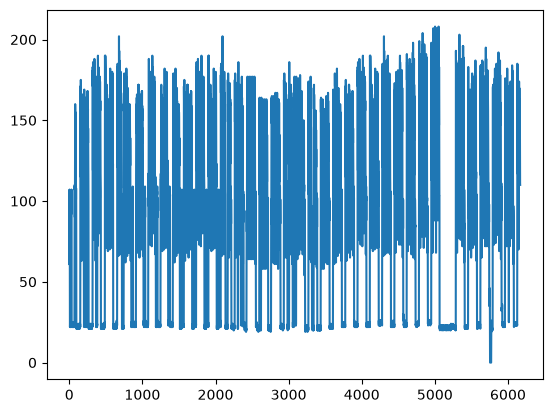

In [9]:
plt.plot(df_frame["평균"])

## 3. 데이터 정제(전처리)

### 3-1.  불필요 데이터 제거 가이드

In [10]:
df_frame.drop(['평균', '날짜'],axis=1, inplace=True)
df_frame

,시간,15분,30분,45분,60분,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,0,62,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,1,96,93,116,113,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,2,106,96,106,107,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,3,92,110,110,109,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,4,108,105,106,108,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,19,152,151,171,139,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20,124,130,128,130,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,21,134,130,125,124,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,22,100,109,120,114,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


### 3-2. 결측치 값 처리

In [14]:
for col in df_frame.columns:
    nul_count ='column: {:>10}\t Percent of NaN value: {:.2f}%'.format(col, 100 * (df_frame[col].isnull().sum() / df_frame[col].shape[0]))
    print(nul_count)

column:         시간	 Percent of NaN value: 0.00%
column:        15분	 Percent of NaN value: 0.00%
column:        30분	 Percent of NaN value: 0.00%
column:        45분	 Percent of NaN value: 0.00%
column:        60분	 Percent of NaN value: 0.00%
column:        생산량	 Percent of NaN value: 0.00%
column:         기온	 Percent of NaN value: 0.00%
column:         풍속	 Percent of NaN value: 0.00%
column:         습도	 Percent of NaN value: 0.00%
column:        강수량	 Percent of NaN value: 0.00%
column:   전기요금(계절)	 Percent of NaN value: 0.00%
column:        day	 Percent of NaN value: 0.00%
column:          d	 Percent of NaN value: 0.00%
column:          m	 Percent of NaN value: 0.00%
column:       공장인원	 Percent of NaN value: 0.00%
column:        인건비	 Percent of NaN value: 0.00%


### 3-3. 데이터 정리

In [15]:
label_cat_names = ['15분','30분','45분','60분']
or_cat_rm_list = ["인건비","전기요금(계절)","공장인원","생산량"]
x_train = []
cost_list = []
for index in range(0,len(df_frame)):
    for col in label_cat_names:
        temp = list(df_frame.drop(or_cat_rm_list,axis=1).drop(label_cat_names,axis=1).iloc[0])
        temp.append(df_frame[col][index])
        cost_list.append(df_frame[or_cat_rm_list].iloc[index])
        x_train.append(temp)

y_labels = []
for index in range(0,len(df_frame)):
    for col in label_cat_names:
        y_labels.append(df_frame[col][index])
y_labels.pop(0)
x_train.pop(len(x_train)-1)
cost_list.pop(len(x_train)-1)
X = np.asarray(x_train)
C = np.asarray(cost_list)
y = np.asarray(y_labels)

## 4. 모델 구축 및 학습

### 4-1. 사용할 모델 구축, 학습 및 검증

In [16]:
# 필요한 패키지 불러오기
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.utils.random import sample_without_replacement
from sklearn.model_selection import train_test_split

In [17]:

# 학습 및 검증데이터 분리하기
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)
c_train, c_test, cy_train, cy_test = train_test_split(C, y, test_size=0.3, random_state = 42)

In [18]:
# 랜덤 포레스트 모델 선언
forest_reg = RandomForestRegressor(max_depth=20, random_state=42)
forest_reg.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [20]:
# 예측 모델 추정치 출력
mean_absolute_error(forest_reg.predict(x_train), y_train)

8.110286128657195

In [21]:
# 검증 데이터의 평균 제곱 오차값 출력
mean_absolute_error(forest_reg.predict(x_test), y_test)

8.25144071920162

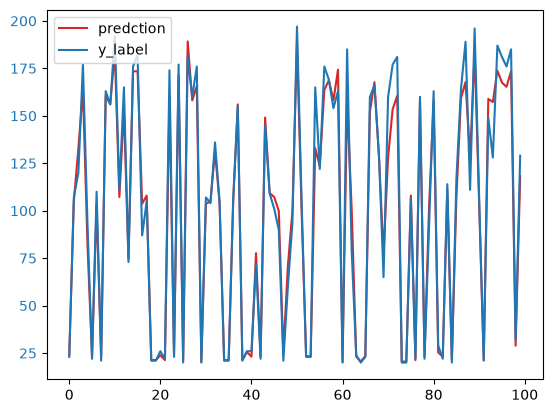

In [22]:
prediction = forest_reg.predict(x_test)
predicted_sample_indexes = sample_without_replacement(len(prediction),100)
color ='tab:red'
plt.tick_params(axis='y', labelcolor=color)
plt.plot(prediction[predicted_sample_indexes], color=color)
color ='tab:blue'
plt.plot(y_test[predicted_sample_indexes],color=color)
plt.tick_params(axis='y', labelcolor=color)
plt.legend(['predction','y_label'])
plt.show()

### 4-2. 자원 최적화 및 분석

In [23]:
# 전기료와 인건비에 대한 목적함수 구성
def build_objective_function_parameters(prediction,x_test, c_test, index =0):
    total_elec_price = prediction[index] * c_test[index][1] /1000 + x_test[index][-1] *1.1 - x_test[index][-2] *1.1
    total_human_cost = c_test[index][2] *50 - x_test[index][-1] *1.1 + x_test[index][-2] *1.1
    return total_elec_price,total_human_cost

In [24]:
from ortools.linear_solver import pywraplp

In [26]:
# SetMinimization()을 활용한 목적함수 구성하기
def objective_function(solver,c_test,cx,cy,x,y,index=0):
    objective = solver.Objective()
    if(c_test[index][0]==1) :
        objective.SetCoefficient(x, cx*2)
        objective.SetCoefficient(y, -cy)

    else:
        objective.SetCoefficient(x, cx//2)
        objective.SetCoefficient(y, -(cy)//2)
    objective.SetMinimization()
    return objective

In [27]:
def get_solution(pred,x_test,c_test,index = 118):
    solver = pywraplp.Solver.CreateSolver('GLOP')
    x = solver.NumVar(1, 2, 'x')
    y = solver.NumVar(1, 75, 'y')
    tep,thc=build_objective_function_parameters(pred,x_test, c_test, index)
    objective = objective_function(solver, c_test, tep, thc, x, y, index)
    objective = solver.Objective()
    constraint2 = solver.Constraint(11, 95)
    constraint2.SetCoefficient(x, 1)
    constraint2.SetCoefficient(y, 2)

    solver.Solve()

    opt_solution = tep * x.solution_value() - thc * y.solution_value()
    print("1이면 낮, 0이면 밤 : ", x.solution_value())
    print("공장인원 수 : ", y.solution_value())
    print("final solution: ", opt_solution)

    if x.solution_value() == 1:
        print("생산량이 ",c_test[index][-2],"일 때, 낮에 공장직원 ", y.solution_value(),"을 투입 시켜야한다.")
    else :
        print("생산량이 ",c_test[index][-2],"일 때, 밤에 공장직원 ", y.solution_value(),"을 투입 시켜야한다.")

In [28]:
c_test[111][-1]

np.float64(72.0)

In [29]:
get_solution(prediction, x_test, c_test, 111)

1이면 낮, 0이면 밤 :  1.0
공장인원 수 :  5.0
final solution:  610.4238440032458
생산량이  0.171837709 일 때, 낮에 공장직원  5.0 을 투입 시켜야한다.
